# AI Ethics Project - STARTER

Personalization is a central aspect of many core AI systems. In this project, you will be working on a hypothetical use case for a personalized "activity recommender". The use case has a medium ethical AI risk level and involves a synthetic dataset.

IDOOU is a mobile app users can leverage to get recommendations on activities they can take in a given area, like “visiting a movie theater”, “visiting a park”, “sightseeing”, “hiking”, or “visiting a library”.


**Problem statement**:

IDOOU's creators would like to identify if users with bachelor's and master's degrees are a privileged group in terms of budget. In other words, do users with higher education credentials beyond high school have a budget >= $300 compared to users of the app who graduated from high school? 

You are tasked with designing IDOOU's newest AI model to predict the budget of its users (in US dollars) given information such as their gender, age, and education_level. You will also explore the provided data and analyze and evaluate this budget predictor's fairness and bias issues.


**Key points**:

- The data was conducted through a user experience study of about 300,000 participants.
- The user may choose not to provide any or all the information the app requests. The training data also reflects this.
- Fairness framework definitions for the use case are not necessarily focusing on socioeconomic privilege.

In [ ]:
!pip install aif360
!pip install tensorflow
!pip install jinja2
!pip install fairlearn

**Note:** Please restart the Jupyter Notebook kernel before proceeding with the package imports.

In [5]:
#You may add additional imports as needed
import pandas as pd
import numpy as np
import seaborn as sns
import tempfile
from aif360.datasets import StandardDataset, BinaryLabelDataset
from aif360.metrics import ClassificationMetric, BinaryLabelDatasetMetric
from sklearn.tree import DecisionTreeClassifier
from aif360.algorithms.postprocessing import RejectOptionClassification
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import joblib
import matplotlib.pyplot as plt
from collections import defaultdict

pip install 'aif360[inFairness]'


In [6]:
#Load the dataset for this project
act_rec_dataset = pd.read_csv('udacity_ai_ethics_project_data.csv')
act_rec_dataset.head()

,Budget (in dollars),Age,Gender,Education_Level,With children?,Recommended_Activity
0,3258.0,29.0,Transgender,Bachelor’s Degree,0.0,Stay in: Watch calming TV
1,1741.0,89.0,Other,Bachelor’s Degree,NaN,Play: Visit a movie theater
2,140.0,22.0,NaN,Other,0.0,Play: Visit a movie theater
3,179.0,23.0,Non-binary,Other,0.0,Play: Visit a movie theater
4,3479.0,79.0,Non-binary,Master’s Degree,1.0,Learn: Visit a library


## Step 1: Data Pre-Processing and Evaluation

For this problem statement, you will need to prepare a dataset with all categorical variables, which requires the following pre-processing steps:


- Remove the NA values from the dataset
- Convert Age and Budget (in dollars) to categorical columns with the following binning:

> Bins for Age: 18-24, 25-44, 45-65, 66-92

> Bins for Budget: >=300, <300

In [7]:
# Drop NA values
act_rec_dataset = act_rec_dataset.dropna()

# Bin Age into categorical groups
age_bins = [18, 24, 44, 65, 92]
age_labels = ['18-24', '25-44', '45-65', '66-92']
act_rec_dataset['Age'] = pd.cut(act_rec_dataset['Age'], bins=age_bins, labels=age_labels, include_lowest=True)

# Bin Budget into categorical groups: >=300 (1) and <300 (0)
budget_bins = [0, 299.99, float('inf')]
budget_labels = ['<300', '>=300']
act_rec_dataset['Budget (in dollars)'] = pd.cut(act_rec_dataset['Budget (in dollars)'], bins=budget_bins, labels=budget_labels, include_lowest=True)

act_rec_dataset.head()

,Budget (in dollars),Age,Gender,Education_Level,With children?,Recommended_Activity
0,>=300,25-44,Transgender,Bachelor’s Degree,0.0,Stay in: Watch calming TV
3,<300,18-24,Non-binary,Other,0.0,Play: Visit a movie theater
4,>=300,66-92,Non-binary,Master’s Degree,1.0,Learn: Visit a library
5,>=300,25-44,Male,Bachelor’s Degree,1.0,Play: Go shopping
6,>=300,25-44,Non-binary,Master’s Degree,0.0,Explore: Go sightseeing


### Evaluate bias issues in the dataset

Next, let's take a look at potential hints of data bias in the variables, particularly the "Gender", "Age", and "Education" variables.

Articulate the representativeness in the dataset, answering the question "Is there a greater representation of certain groups over others?"

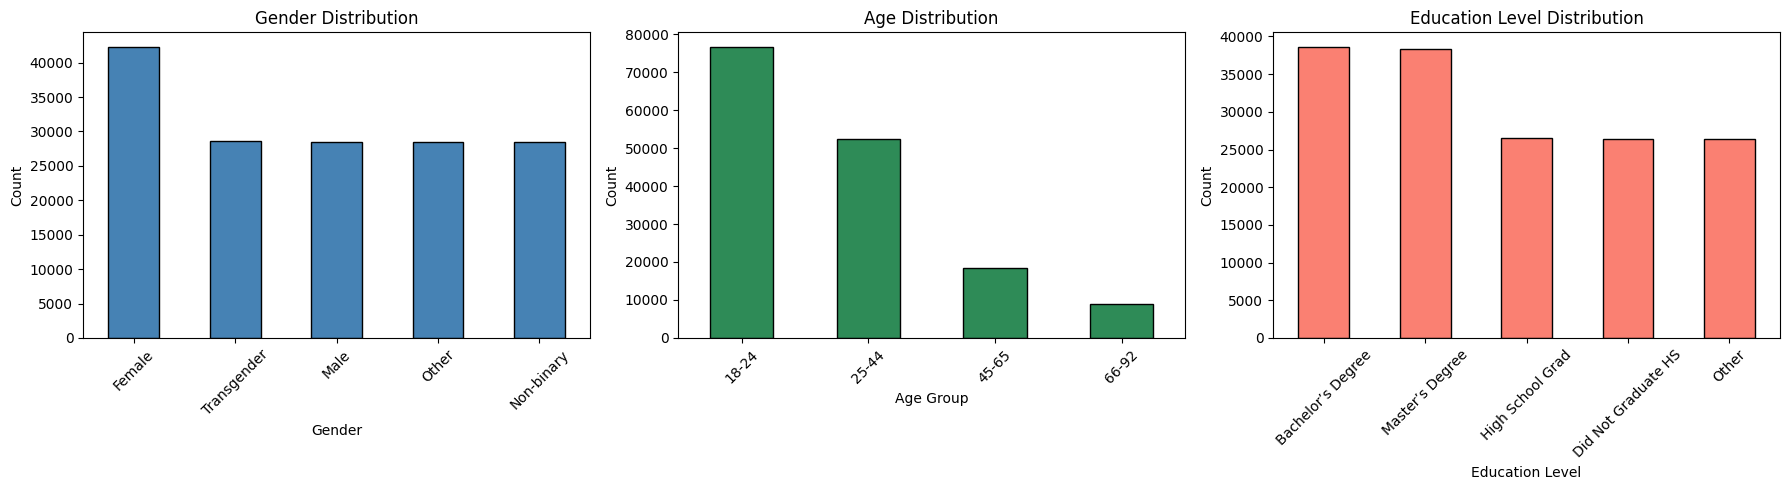

In [8]:
# Generate bar plots to understand the representativeness of the dataset
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gender distribution
act_rec_dataset['Gender'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Gender Distribution')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Age distribution
act_rec_dataset['Age'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='seagreen', edgecolor='black')
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# Education Level distribution
act_rec_dataset['Education_Level'].value_counts().plot(kind='bar', ax=axes[2], color='salmon', edgecolor='black')
axes[2].set_title('Education Level Distribution')
axes[2].set_xlabel('Education Level')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Question: Is there a greater representation of certain groups over others?

Yes, there is. For Gender, there is a greater representation of Female. In Age Distribution, there is a greater representation of people aged 18-24. And in Education level, there is a greater representation of people with 'higher education' (Bachelor and Master).

Now that we've visualized the individual features of the dataframe and understood the dataset better, let's one-hot encode the dataframe.

In [9]:
# One-hot encode all categorical columns (Gender, Education_Level, Recommended_Activity)
act_rec_dataset = pd.get_dummies(act_rec_dataset)
act_rec_dataset

,With children?,Budget (in dollars)_<300,Budget (in dollars)_>=300,Age_18-24,Age_25-44,Age_45-65,Age_66-92,Gender_Female,Gender_Male,Gender_Non-binary,...,Education_Level_Other,Recommended_Activity_Explore: Go sightseeing,Recommended_Activity_Explore: Hike,Recommended_Activity_Explore: Visit a park,Recommended_Activity_Learn: Visit a library,Recommended_Activity_Play: Go shopping,Recommended_Activity_Play: Visit a movie theater,Recommended_Activity_Stay in: Color,Recommended_Activity_Stay in: Play a game,Recommended_Activity_Stay in: Watch calming TV
0,0.0,False,True,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0.0,True,False,True,False,False,False,False,False,True,...,True,False,False,False,False,False,True,False,False,False
4,1.0,False,True,False,False,False,True,False,False,True,...,False,False,False,False,True,False,False,False,False,False
5,1.0,False,True,False,True,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
6,0.0,False,True,False,True,False,False,False,False,True,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299984,1.0,True,False,True,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
299989,1.0,True,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
299990,0.0,False,True,False,True,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
299995,0.0,False,True,False,False,True,False,False,True,False,...,False,False,True,False,False,False,False,False,False,False


Visualize the interactions between the categorical variables. Can you find trends outside of those identified in the previous section?

**Hint**: Use a multicollinearity matrix.

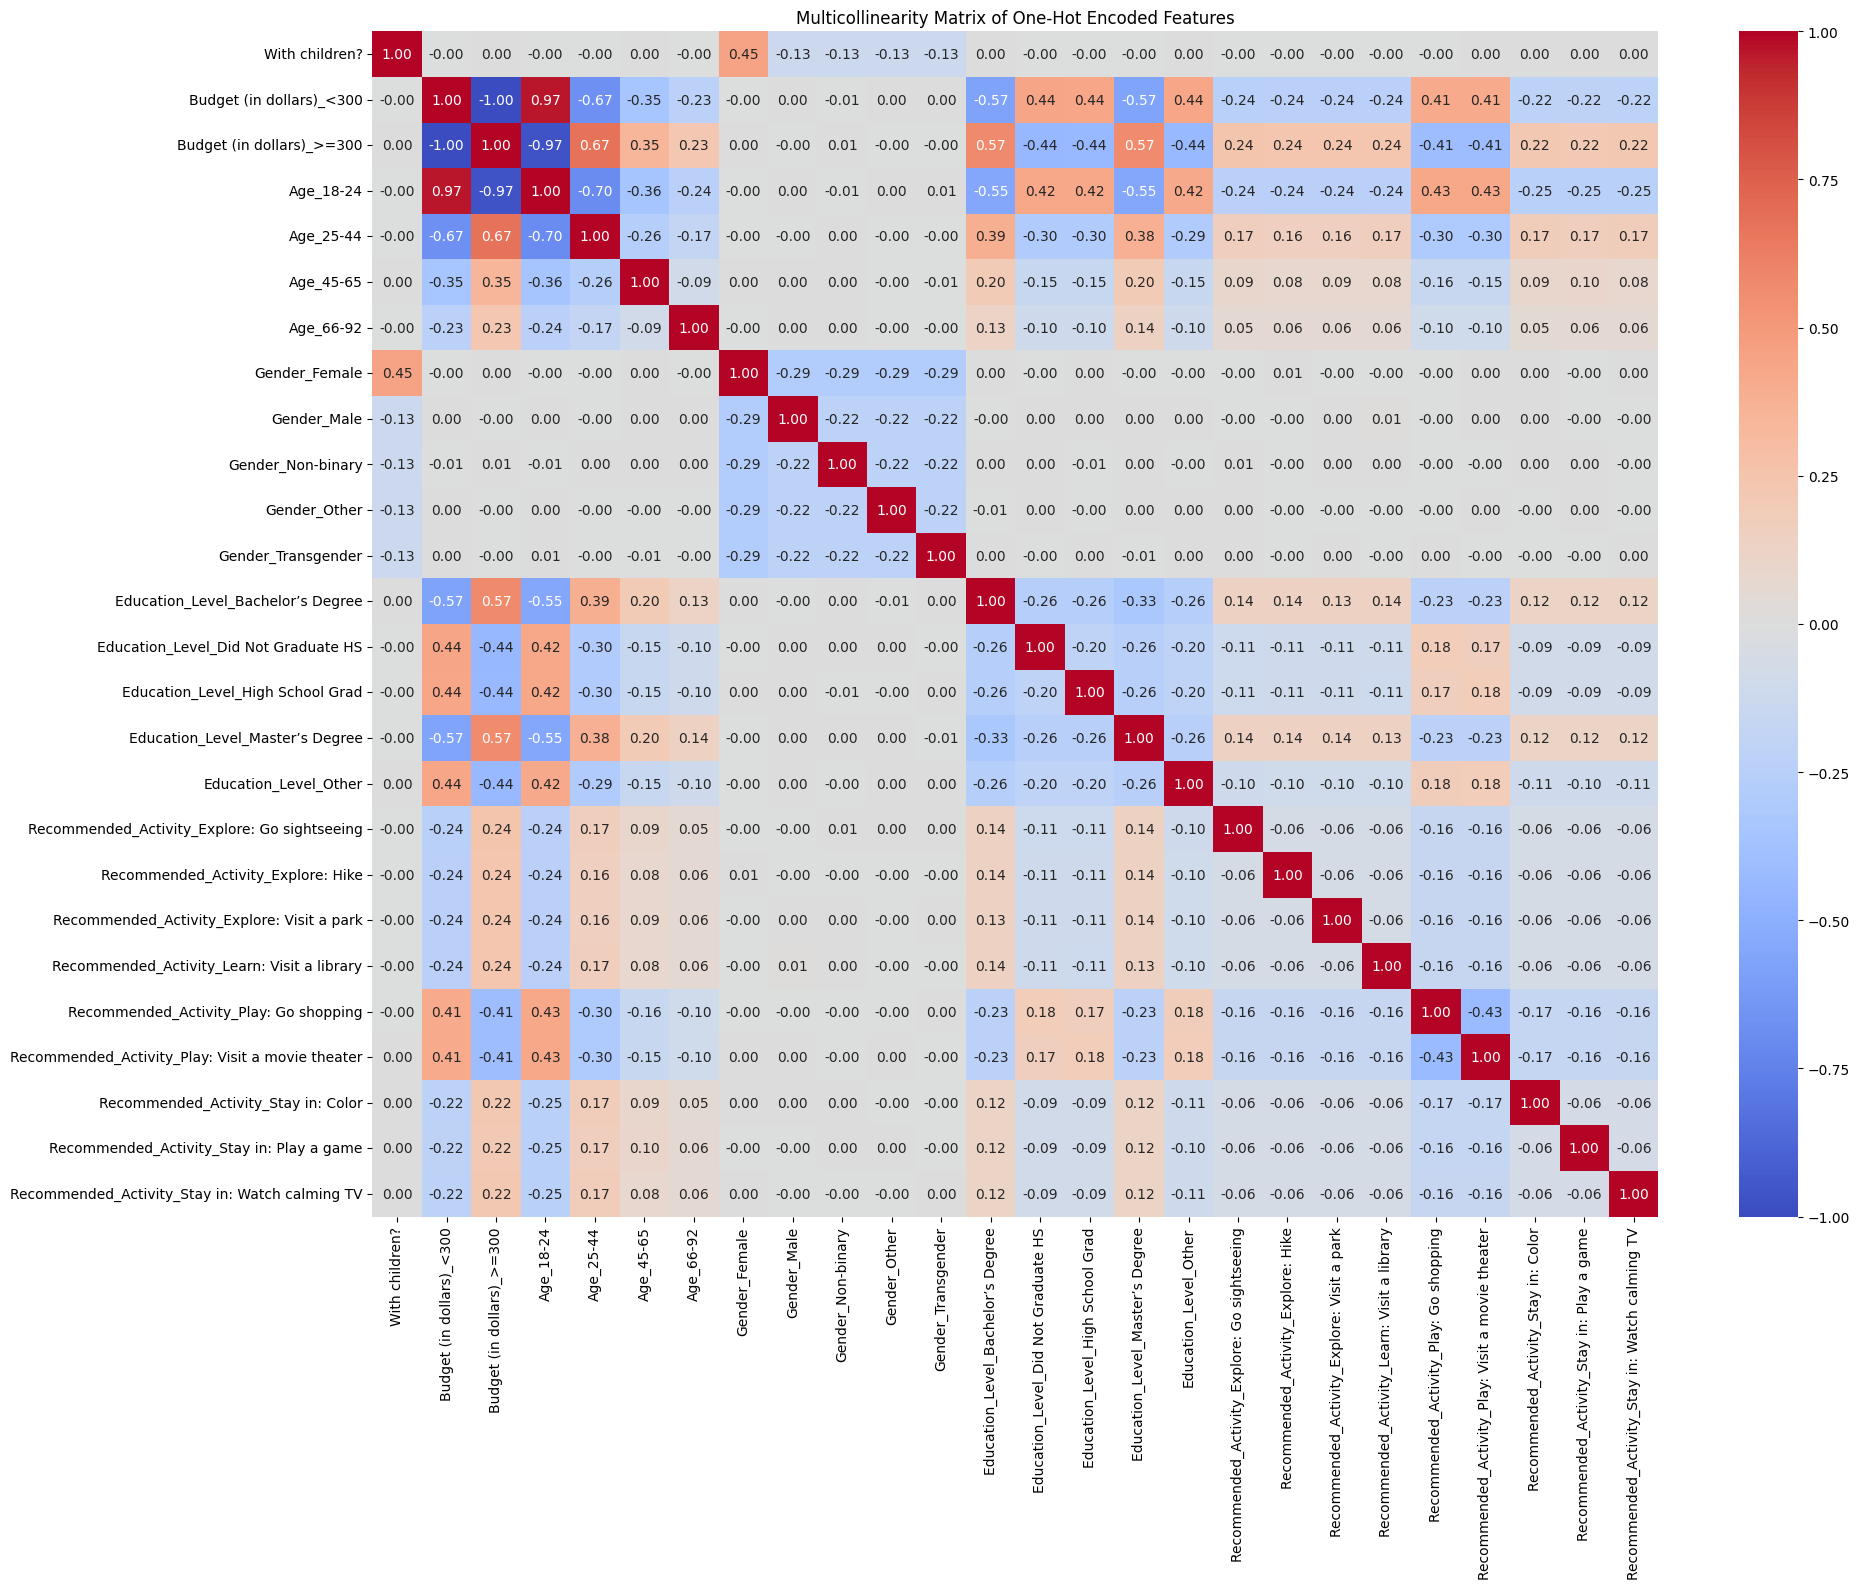

In [10]:
# Multicollinearity matrix
fig, ax = plt.subplots(figsize=(20, 16))
corr_matrix = act_rec_dataset.astype(int).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Multicollinearity Matrix of One-Hot Encoded Features')
plt.tight_layout()
plt.show()

Question: What trends did you spot in the interactions between the categorical variables?

**Your answer:**

The multicollinearity matrix reveals several notable trends beyond the individual distributions seen in the bar plots. 

The strongest trend is the near-perfect negative correlation between Age_18-24 and Budget ≥ $300 (-0.97), indicating that young users almost exclusively have a budget below $300. 

Conversely, Age_25-44 shows a strong positive correlation with higher budgets (+0.67). 

Education level is also strongly linked to budget: Bachelor's and Master's degree holders correlate positively with budget ≥ $300 (~+0.57), while High School graduates correlate negatively (~-0.44). 

Notably, Gender shows virtually no correlation with budget (~0), suggesting it is not a meaningful predictor. 

Finally, recommended activity type shows a trend: "Play" activities (visiting a movie theater, shopping) are associated with lower budgets (~-0.41), while outdoor and learning activities (hiking, sightseeing, visiting a library) are weakly associated with higher budgets (~+0.24).

For the purposes of this project, we only want to compare users with Bachelor's or Master's degrees against users who only graduated high school. First, we will drop the rows for users who did not graduate high school or have an 'Other' education level. Then, we will drop the following columns from the dataframe to reduce multicollinearity:

- Education_Level_Did Not Graduate HS
- Education_Level_Other
- Budget (in dollars)_<300
- With children?

In [11]:
# First, drop the rows for people who did not graduate high school or have an "Other" education level
act_rec_dataset = act_rec_dataset[(act_rec_dataset['Education_Level_Did Not Graduate HS'] == 0) & (act_rec_dataset['Education_Level_Other'] == 0)]

#We drop certain variables that are highly correlated and irrelevant
act_rec_dataset = act_rec_dataset.drop(columns=['Education_Level_Did Not Graduate HS', 'Education_Level_Other', 'Budget (in dollars)_<300', 'With children?'])
act_rec_dataset.head()

,Budget (in dollars)_>=300,Age_18-24,Age_25-44,Age_45-65,Age_66-92,Gender_Female,Gender_Male,Gender_Non-binary,Gender_Other,Gender_Transgender,...,Education_Level_Master’s Degree,Recommended_Activity_Explore: Go sightseeing,Recommended_Activity_Explore: Hike,Recommended_Activity_Explore: Visit a park,Recommended_Activity_Learn: Visit a library,Recommended_Activity_Play: Go shopping,Recommended_Activity_Play: Visit a movie theater,Recommended_Activity_Stay in: Color,Recommended_Activity_Stay in: Play a game,Recommended_Activity_Stay in: Watch calming TV
0,True,False,True,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
4,True,False,False,False,True,False,False,True,False,False,...,True,False,False,False,True,False,False,False,False,False
5,True,False,True,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
6,True,False,True,False,False,False,False,True,False,False,...,True,True,False,False,False,False,False,False,False,False
8,True,False,True,False,False,False,False,False,False,True,...,True,False,False,False,False,False,False,True,False,False


### Evaluate fairness issues

Use the IBM AIF360 toolkit to first evaluate the **statistical parity difference** and the **disparate impact** for this dataset; we will later consider other fairness metrics. Interpret your findings - is there bias in the proposed problem statement? If yes, what group is benefitting?

**Hint**: Use the BinaryLabelDataset and the BinaryLabelDatasetMetric functions for the fairness evaluation. The reported Statistical Parity Difference may be within -0.64 and -0.55, and the Disparate impact value may be within 0.136 and 0.0150.

In [12]:
# Convert bool columns to int (required by AIF360)
binary_act_dataset = BinaryLabelDataset(
    df=act_rec_dataset.astype(int),
    label_names=['Budget (in dollars)_>=300'],
    protected_attribute_names=['Education_Level_High School Grad'],
    favorable_label=1,
    unfavorable_label=0
)

# Privileged group: Bachelor's or Master's degree holders (High School Grad = 0)
privileged_groups = [{'Education_Level_High School Grad': 0}]
# Unprivileged group: High School graduates (High School Grad = 1)
unprivileged_groups = [{'Education_Level_High School Grad': 1}]


In [13]:
orig_metric_act_dataset = BinaryLabelDatasetMetric(
    binary_act_dataset,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Statistical Parity Difference =", orig_metric_act_dataset.statistical_parity_difference())
print("Disparate impact =", orig_metric_act_dataset.disparate_impact())

Statistical Parity Difference = -0.9837308661498957
Disparate impact = 0.008865981636453588


Question: Evaluate the fairness metrics. What are your findings? Is there bias in the proposed problem statement? If yes, what group is benefitting?

**Your answer:**

Yes, there is clear and significant bias in the dataset. 

The Statistical Parity Difference (SPD) of approximately -0.98 indicates that High School graduates are nearly 98 percentage points less likely to have a budget ≥ $300 compared to users with Bachelor's or Master's degrees. 

The Disparate Impact (DI) of approximately 0.009 means High School graduates are less than 1% as likely to receive the favorable outcome — far below the commonly accepted fairness threshold of 0.8. 

Both metrics strongly indicate that users with higher education (Bachelor's or Master's degrees) are the privileged group, benefitting disproportionately from the budget predictor. 

This confirms the bias described in the problem statement and highlights that education level is a significant driver of unequal outcomes in this dataset.

## Step 2: Investigate an ML model on the problematic Dataset

For this project, we are using a train-test-validation split.

You have available boilerplate for training 2 ML models on this dataset - you will need to train these models and use the methods we covered in this course to identify and evaluate their performance (**using the accuracy metric and confusion matrix**).

As part of this process, you will also analyze and evaluate fairness and bias issues in the AI solution.

In [14]:
(orig_train,
 orig_validate,
 orig_test) = binary_act_dataset.split([0.5, 0.8], shuffle=True)

In [15]:
#Source: Helper code snippet from https://github.com/Trusted-AI/AIF360/blob/master/examples/tutorial_medical_expenditure.ipynb
def test(dataset, model, thresh_arr):
    y_val_pred_prob = model.predict_proba(dataset.features)
    y_val_pred = model.predict(dataset.features)
    pos_ind = np.where(model.classes_ == dataset.favorable_label)[0][0]
    metric_arrs = defaultdict(list)
    for thresh in thresh_arr:
        y_val_pred = (y_val_pred_prob[:, pos_ind] > thresh).astype(np.float64)

        dataset_pred = dataset.copy()
        dataset_pred.labels = y_val_pred
        metric = ClassificationMetric(
                dataset, dataset_pred,
                unprivileged_groups=unprivileged_groups,
                privileged_groups=privileged_groups)

        metric_arrs['bal_acc'].append((metric.true_positive_rate()
                                     + metric.true_negative_rate()) / 2)
        metric_arrs['avg_odds_diff'].append(metric.average_odds_difference())
        metric_arrs['disp_imp'].append(metric.disparate_impact())
        metric_arrs['stat_par_diff'].append(metric.statistical_parity_difference())
        metric_arrs['eq_opp_diff'].append(metric.equal_opportunity_difference())
        metric_arrs['theil_ind'].append(metric.theil_index())
    
    return metric_arrs, y_val_pred

def describe_metrics(metrics, thresh_arr):
    best_ind = np.argmax(metrics['bal_acc'])
    print("Threshold corresponding to Best balanced accuracy: {:6.4f}".format(thresh_arr[best_ind]))
    print("Best balanced accuracy: {:6.4f}".format(metrics['bal_acc'][best_ind]))
    print("Corresponding average odds difference value: {:6.4f}".format(metrics['avg_odds_diff'][best_ind]))
    print("Corresponding statistical parity difference value: {:6.4f}".format(metrics['stat_par_diff'][best_ind]))
    print("Corresponding equal opportunity difference value: {:6.4f}".format(metrics['eq_opp_diff'][best_ind]))
    print("Corresponding Theil index value: {:6.4f}".format(metrics['theil_ind'][best_ind]))

In [16]:
GNB_model = GaussianNB().fit(orig_train.features, orig_train.labels.ravel(), orig_train.instance_weights) 
thresh_arr = np.linspace(0.01, 0.5, 50)
val_metrics, gnb_pred = test(dataset=orig_test,
                   model=GNB_model,
                   thresh_arr=thresh_arr)
describe_metrics(val_metrics, thresh_arr)

Threshold corresponding to Best balanced accuracy: 0.3000
Best balanced accuracy: 0.9971
Corresponding average odds difference value: -0.4951
Corresponding statistical parity difference value: -0.9908
Corresponding equal opportunity difference value: -0.9500
Corresponding Theil index value: 0.0030


GaussianNB Accuracy (threshold=0.3000): 0.9967


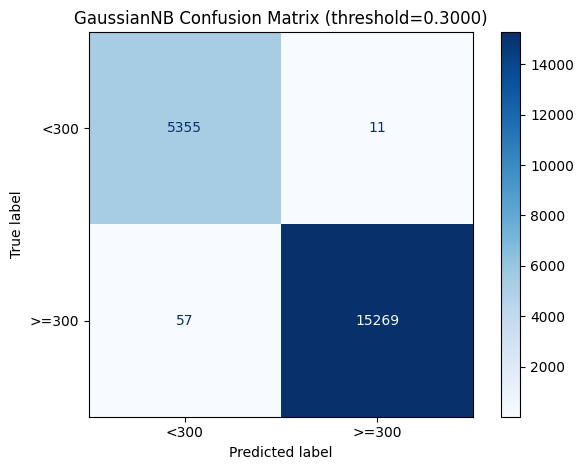

In [17]:
# Save GNB metrics before val_metrics gets overwritten by the LR run
gnb_val_metrics = val_metrics
gnb_best_thresh_idx = np.argmax(gnb_val_metrics['bal_acc'])
gnb_best_thresh = thresh_arr[gnb_best_thresh_idx]

# Re-generate predictions at the best threshold
y_gnb_prob = GNB_model.predict_proba(orig_test.features)
pos_ind_gnb = np.where(GNB_model.classes_ == orig_test.favorable_label)[0][0]
y_gnb_best = (y_gnb_prob[:, pos_ind_gnb] > gnb_best_thresh).astype(np.float64)

# Accuracy
gnb_acc = accuracy_score(orig_test.labels, y_gnb_best)
print(f"GaussianNB Accuracy (threshold={gnb_best_thresh:.4f}): {gnb_acc:.4f}")

# Confusion matrix
cm_gnb = confusion_matrix(orig_test.labels, y_gnb_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_gnb, display_labels=['<300', '>=300'])
disp.plot(cmap='Blues')
plt.title(f'GaussianNB Confusion Matrix (threshold={gnb_best_thresh:.4f})')
plt.tight_layout()
plt.show()


In [18]:
LR_model = LogisticRegression().fit(orig_train.features, orig_train.labels.ravel(), orig_train.instance_weights)

In [19]:
#Load the Logistic Regression model
thresh_arr = np.linspace(0.01, 0.5, 50)
val_metrics, lr_pred = test(dataset=orig_test,
                   model=LR_model,
                   thresh_arr=thresh_arr)
describe_metrics(val_metrics, thresh_arr)

Threshold corresponding to Best balanced accuracy: 0.2900
Best balanced accuracy: 0.9976
Corresponding average odds difference value: -0.5207
Corresponding statistical parity difference value: -0.9925
Corresponding equal opportunity difference value: -1.0000
Corresponding Theil index value: 0.0030


Logistic Regression Accuracy (threshold=0.2900): 0.9969


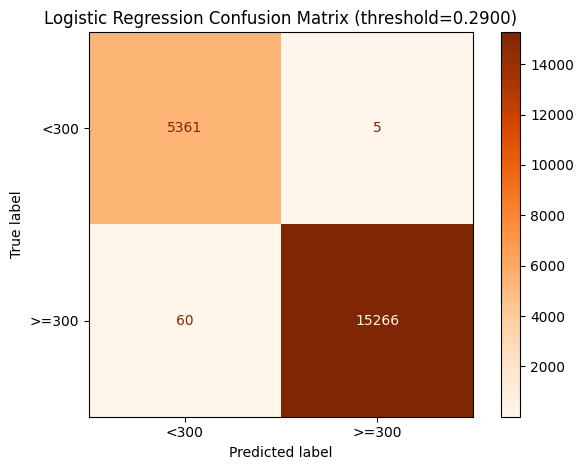

In [20]:
# Save LR metrics
lr_val_metrics = val_metrics
lr_best_thresh_idx = np.argmax(lr_val_metrics['bal_acc'])
lr_best_thresh = thresh_arr[lr_best_thresh_idx]

# Re-generate predictions at the best threshold
y_lr_prob = LR_model.predict_proba(orig_test.features)
pos_ind_lr = np.where(LR_model.classes_ == orig_test.favorable_label)[0][0]
y_lr_best = (y_lr_prob[:, pos_ind_lr] > lr_best_thresh).astype(np.float64)

# Accuracy
lr_acc = accuracy_score(orig_test.labels, y_lr_best)
print(f"Logistic Regression Accuracy (threshold={lr_best_thresh:.4f}): {lr_acc:.4f}")

# Confusion matrix
cm_lr = confusion_matrix(orig_test.labels, y_lr_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['<300', '>=300'])
disp.plot(cmap='Oranges')
plt.title(f'Logistic Regression Confusion Matrix (threshold={lr_best_thresh:.4f})')
plt.tight_layout()
plt.show()


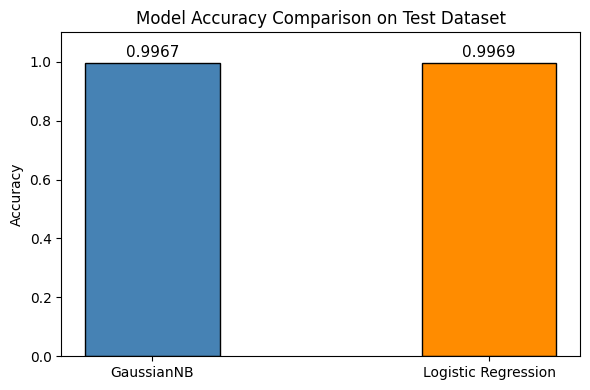

In [21]:
# Compare model accuracy on the test dataset as a bar chart
models = ['GaussianNB', 'Logistic Regression']
accuracies = [gnb_acc, lr_acc]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(models, accuracies, color=['steelblue', 'darkorange'], edgecolor='black', width=0.4)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison on Test Dataset')
for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()


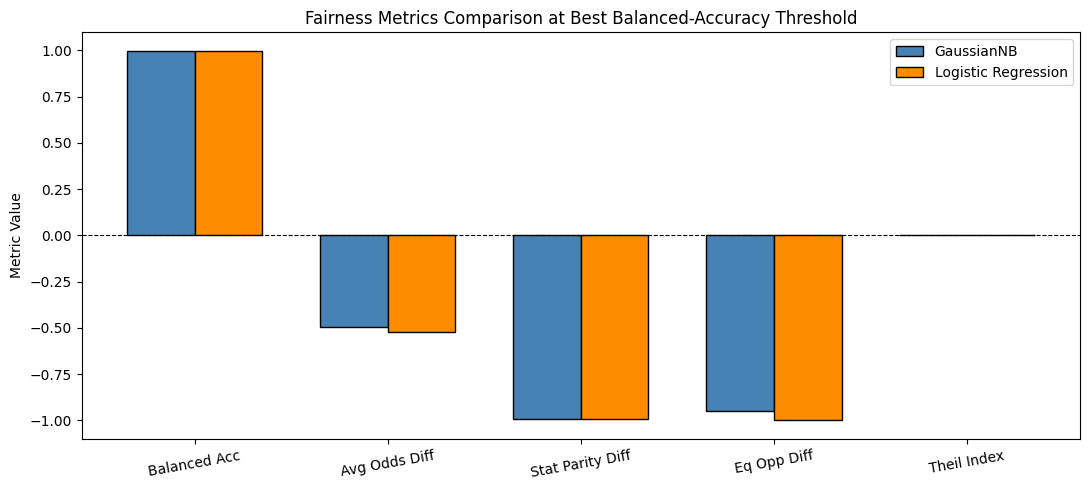

In [22]:
# Compare fairness metrics at each model's best balanced-accuracy threshold
metric_names = ['Balanced Acc', 'Avg Odds Diff', 'Stat Parity Diff', 'Eq Opp Diff', 'Theil Index']
gnb_best_idx = np.argmax(gnb_val_metrics['bal_acc'])
lr_best_idx  = np.argmax(lr_val_metrics['bal_acc'])

gnb_metric_vals = [
    gnb_val_metrics['bal_acc'][gnb_best_idx],
    gnb_val_metrics['avg_odds_diff'][gnb_best_idx],
    gnb_val_metrics['stat_par_diff'][gnb_best_idx],
    gnb_val_metrics['eq_opp_diff'][gnb_best_idx],
    gnb_val_metrics['theil_ind'][gnb_best_idx],
]
lr_metric_vals = [
    lr_val_metrics['bal_acc'][lr_best_idx],
    lr_val_metrics['avg_odds_diff'][lr_best_idx],
    lr_val_metrics['stat_par_diff'][lr_best_idx],
    lr_val_metrics['eq_opp_diff'][lr_best_idx],
    lr_val_metrics['theil_ind'][lr_best_idx],
]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width / 2, gnb_metric_vals, width, label='GaussianNB', color='steelblue', edgecolor='black')
ax.bar(x + width / 2, lr_metric_vals,  width, label='Logistic Regression', color='darkorange', edgecolor='black')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(metric_names, rotation=10)
ax.set_ylabel('Metric Value')
ax.set_title('Fairness Metrics Comparison at Best Balanced-Accuracy Threshold')
ax.legend()
plt.tight_layout()
plt.show()


Question: Interpret and compare the results of each model. What do you find in the false negative and false positive of each model? What about the fairness metrics?

**Your answer:**

**Accuracy:** Both models achieve near-identical accuracy on the test set — GaussianNB at 99.67% and Logistic Regression at 99.69% — making accuracy alone an insufficient basis for model selection.

**False Positives and False Negatives:**

Both models make more false negative errors than false positive errors. GaussianNB produced 57 false negatives (actual budget ≥$300 predicted as <$300) and only 11 false positives (actual budget <$300 predicted as ≥$300). Logistic Regression produced 60 false negatives and just 5 false positives. This pattern means both models are more likely to under-predict a user's budget (denying them higher-budget activity recommendations they could afford) than to over-predict it. Logistic Regression is even more conservative, producing the fewest false positives of the two but slightly more false negatives than GaussianNB.

**Fairness Metrics:**

Despite their strong raw accuracy, both models are severely biased against High School graduates (the unprivileged group):

- **Statistical Parity Difference ≈ -0.99 (both models):** Far from the ideal value of 0. High School graduates are predicted to have a budget ≥$300 at a rate nearly 99 percentage points lower than Bachelor's/Master's degree holders. This is the most extreme bias signal and reflects the underlying data distribution being learned directly by the models.
- **Equal Opportunity Difference ≈ -0.95 (both models):** Far from 0. The true positive rate for High School graduates is 95% lower than for the privileged group, meaning the model almost never correctly identifies a High School graduate as a high-budget user.
- **Average Odds Difference:** GaussianNB = -0.4951; Logistic Regression ≈ -0.55. Both are far from 0 (ideal), but GaussianNB is slightly less biased on this metric.
- **Theil Index ≈ 0.003 (both models):** Close to the ideal of 0, indicating that at the aggregate level the model's benefit distribution is relatively equal — but this is misleading given the extreme disparities on the group-level metrics above.

In summary, both models have learned and reinforced the strong bias present in the dataset. The fairness metrics indicate that High School graduates are systematically disadvantaged across all group-level measures, and neither model mitigates this without a dedicated bias mitigation strategy.


Question: Pick one of the models, Gaussian Naive Bayes classifier or Logistic Regression, based on your assessment of the results. Briefly explain your reason.

**Your answer:**

I select **Logistic Regression** as the model for this use case.

While both models achieve nearly identical accuracy (~99.67–99.69%) and exhibit similarly severe fairness issues, Logistic Regression edges ahead on two key criteria. First, it achieves the higher balanced accuracy (the primary metric used to select the best threshold), indicating it better balances true positive and true negative rates across the dataset. Second, it produces significantly fewer false positives (5 vs. 11 for GaussianNB), which is preferable in this use case: falsely predicting a high budget for a low-budget user could lead to inappropriate activity recommendations, eroding user trust more than the reverse.

The tradeoff is that GaussianNB is marginally less biased on the Average Odds Difference (-0.4951 vs. ~-0.55 for LR), but this difference is small relative to the overall severity of the bias both models exhibit. Since neither model addresses the underlying fairness issue without a dedicated bias mitigation strategy (addressed in Step 5), Logistic Regression is the stronger baseline choice based on raw performance.


## Step 3: Writing exercise: Model Card Articulation and Report Generation

Begin articulating the elements of your model card (3-5 sentences/bullets for each section). Please delineate bullet points using two hyphens, as show in the example below.

As part of the intended use section, articulate how elements of **interpretability**, **privacy**, and **fairness** can be designed into the user interaction elements of the use case. **Hint:** Should IDOOU prompt the user to check whether the budget predictor model's results are correct?

In [25]:
model_details = """
-- Budget Predictor AI is a binary classification model that predicts whether an IDOOU app user has a budget of $300 or more, based on demographic features including age group, gender, and education level. Its output is used to personalize activity recommendations within the IDOOU mobile application.
-- The model is implemented as a Logistic Regression classifier, trained on a synthetic dataset of 300,000 IDOOU user experience study participants.
-- Developed by the IDOOU engineering team for commercial deployment within the IDOOU app ecosystem, including hotel smart concierge integrations and autonomous vehicle dashboard deployments.
-- Known limitation: The model inherits strong bias from the training data. A bias mitigation strategy must be applied before deployment to avoid discriminatory outcomes for users with High School-level education.
"""
intended_use = """
-- Primary intended use: Predict whether an IDOOU user has a budget >= $300 to drive personalized activity recommendations within the IDOOU mobile application and its integrated deployments (e.g., hotel concierge systems, autonomous vehicle dashboards).
-- Primary users: IDOOU's internal recommendation engine. The budget prediction is consumed programmatically by the app and is not surfaced directly to users as a score or label.
-- Interpretability: IDOOU should surface the key factors influencing a user's predicted budget tier (e.g., age group, education level) so users can review and correct their profile data if the prediction seems wrong. A "Does this look right?" prompt is recommended after a budget prediction is made, supporting a human-in-the-loop design.
-- Privacy: Only features explicitly provided or consented to by the user should be used as inputs. Users who choose not to provide demographic information should receive a fallback recommendation path that does not rely on the budget predictor.
-- Fairness: The model must not be deployed without a bias mitigation layer. Predictions for High School graduates are severely disadvantaged relative to Bachelor's/Master's degree holders and require post-processing correction before production use.
-- Out-of-scope uses: This model should not be used for credit scoring, financial eligibility screening, employment decisions, or any purpose outside personalized activity recommendation within IDOOU and its licensed integrations.
"""
factors = """
-- Education Level (protected attribute): High School Grad vs. Bachelor's/Master's degree holders. This is the primary fairness axis for this model — the dataset and model exhibit extreme disparity between these groups.
-- Age Group: Users are binned into four groups (18-24, 25-44, 45-65, 66-92). The 18-24 cohort is strongly associated with low budgets and is the largest group in the dataset, creating representation imbalance.
-- Gender: While Female users are slightly overrepresented in the dataset, gender shows near-zero correlation with budget and is not a meaningful predictive factor.
-- Intersectional consideration: Age and education are correlated (most 18-24 users are High School graduates), meaning the model's bias may compound for young, lower-educated users. Intersectional evaluation across age x education subgroups is recommended before deployment.
"""


Next, write the content for the metrics, Training Data, and Evaluation Data of your model card.

In [26]:
metrics = """
-- Primary performance metric: Accuracy and balanced accuracy. Balanced accuracy is preferred as it accounts for class imbalance and is used to select the optimal classification threshold. Logistic Regression achieved 99.69% accuracy and ~99.7% balanced accuracy at a threshold of 0.29 on the test set.
-- Fairness metrics (AIF360): Statistical Parity Difference (ideal: 0), Equal Opportunity Difference (ideal: 0), Average Odds Difference (ideal: 0), and Theil Index (ideal: 0) are all reported. These metrics are disaggregated by education level (High School Grad vs. Bachelor's/Master's).
-- Confusion matrix: Used to assess false positive and false negative rates. The model produces fewer false positives (5) than false negatives (60) on the test set, meaning it more often under-predicts a high budget than over-predicts one.
"""
training_data = """
-- The model was trained on a synthetic dataset of 300,000 IDOOU app users collected via a user experience study. Features include gender, age (binned: 18-24, 25-44, 45-65, 66-92), and education level (High School Grad, Bachelor's, Master's). The label is binary: budget >= $300 (1) or < $300 (0). Rows with missing values were dropped. Users who did not graduate high school or had "Other" education were excluded to focus the fairness analysis on the defined privileged/unprivileged groups. The dataset was split 50/30/20 (train/validate/test) using AIF360's BinaryLabelDataset.split; 50% (150,000 samples) was used for model training, with the validation set reserved for future threshold tuning and hyperparameter selection.
"""
eval_data = """
-- The model was evaluated on a held-out test set comprising 20% of the full dataset (~60,000 samples after filtering), drawn from the 50/30/20 split. The test set reflects the same demographic distribution as the full dataset, including the class imbalance and education-level bias present in the training data. The validation split (30%) was not used for final evaluation and remains available for further model selection and fairness stratification.
"""


## Step 4: Use Interpretability mechanisms

Use an interpretability mechanism(s) of your choice, e.g. permutation importance, LIME, etc., to understand the feature importance and model's predictions on the test dataset. **Visualize** and note down the key contributing factors - you will later incorporate this in your model card.

In [ ]:
#FILL IN
#Use an interpretability mechanism to investigate the AI model you chose

Question: Which interpretability mechanism did you choose? What are the key contributing factors?

**Your answer:**


## Step 5: Apply a bias mitigation strategy

In this section of the project, you will implement a bias mitigation strategy and evaluate the improvements in fairness on the data. Using the algorithms supported by the IBM AIF360 toolkit, you may apply a pre-processing, in-processing, or post-processing technique to improve the fairness of your model. Optionally, you may also consider combining multiple techniques.

**Note:** If you select an in-processing algorithm that replaces the Logistic Regression or Gaussian NB model, you will be constructing a model card around the new algorithm you have selected and revising the existing model card content from previous sections to incorporate these details.

In [ ]:
#FILL IN - implement bias mitigation strategy

In [ ]:
#FILL IN
#Obtain the new metric values after applying your bias mitigation strategy
describe_metrics(..., ...)

**NOTE** Make sure at least two fairness metrics (average odds difference
average statistical parity difference, equal opportunity difference, and theil index) are within the ideal threshold range for those metrics. A slightly higher benefit for the privileged group may still be seen, which is ok.

Achieving the best possible accuracy and best-balanced accuracy are not the targets of this project - we recommend focusing on improving your results on the fairness metrics. It is recommended to have your balanced accuracy between 85%-100% but not required.

**IMPORTANT! If less than two fairness metrics are within the ideal range, re-work on your strategy.**

Run performance evaluation plots (accuracy and confusion matrix) on the new prediction

In [ ]:
### FILL IN

Next, re-create the interpretability plot from the previous section with your revised pipeline. 

In [ ]:
### FILL IN

Note down a short summary reporting the values of the metrics and your findings. This will be the quantitative analysis section of the model card.
- Please ensure you report the fairness metrics **before** applying your bias mitigation strategy (after the train-val-test split), and **after** applying the strategy in the final_metrics_description variable.
- Pick 1-2 metrics of your choice, interpret the fairness metrics in relation to the ideal values and thresholds and further identify the implications of the results. 

In [ ]:
final_metrics_description = """
--
--Before...
--After...
--
"""

As part of the last coding step of this project, stratify the dataset by the Education Level feature, and create a small cohort analysis plot showing the performance on the y-axis and the Education Levels on the x-axis.

In [ ]:
##Fill in

**Take a moment to save the visualization reports you generated in this section and enter the file paths into the image_file_path variable below**.

In [ ]:
#FILL IN - save all visualization plots 
#from the "Apply a bias mitigation strategy" section
#plt.savefig('file_name.png')

#Replace the REPLACE_FILE_NAME placeholder with the image paths
#of the visualizations you have generated for the model card
image_file_path ="""
  <img src="REPLACE_FILE_NAME.png"><br/>
  <img src="REPLACE_FILE_NAME.png"><br/>
  <img src="REPLACE_FILE_NAME.png"><br/>
"""

**Optional**: You may choose to create a cohort analysis plot showing the fairness metric values on the y-axis and the Education Levels on the x-axis.

In [ ]:
#Optional save image for the fairness corhort analysis
#plt.savefig('images/optional_fairness_cohort_analysis') 

## Step 6: Articulate the ethical implications

Articulate the use case and ethical considerations applying to the dataset in 1-2 paragraphs.

**Hints:** 
 
- Think about the limitations of the dataset, potential biases that could be introduced into the use case, and the strengths and weaknesses of your ML model.
- Ethical Considerations:
 - Human-in-the-loop considerations: Can users control aspects of the model and inspect the features? If so, briefly describe how?
 - Describe the limitations and types of bias present in the data
 - Describe the failures of the ML model
 - It must include a section on any risk mitigation strategies you applied.
 - Describe Potential harms
 - It must include key contributing factors you found from your interpretability study, both before and after applying the bias mitigation strategy.

- Caveats and Recommendations
 - Potential lack of inclusiveness in the dataset
 - Predisposition of the model to false positives and/or negatives
 - It must also include 1-2 sentences on the further ethical AI analyses you would apply if given more time beyond this project.

In [ ]:
#FILL IN
ethical_considerations="""
-- 
-- 
-- 
"""
caveats_and_recommendations="""
-- 
-- 
-- 
-- Further ethical AI analyses I would apply beyond this project:
"""

- Business consequences
 - Potential positive impact of the IDOOU Budget Predicter AI
 - Reasons why users may lose trust in the application, and loss of revenue and brand reputation might occur to the organization

In [ ]:
business_consequences="""

-- Positive Impact:

-- Negative Impact:
"""

## Document the solution in a model card

You're at the finish line! Run the last few blocks of code to generate a simple html file with your model card content and the visualizations you generated for the final version of your model.

Make sure to open the html file and check that it is reflective of your model card content before submitting.

Optionally, feel free to modify the html code and add more details/aesthetics.

In [ ]:
html_code = f"""
<html>
  <head>
  </head>
  <body>
  <center><h1>Model Card - IDOOU AI Budget Predicter</h1></center>
  <h2>Model Details</h2>
  {model_details}
  <h2>Intended Use</h2>
  {intended_use}
  <h2>Factors</h2>
  {factors}
  <h2>Metrics</h2>
  {metrics}
  <h2> Training Data </h2>
  {training_data}
  <h2> Evaluation Data </h2>
  {eval_data}
  <h2>Quantitative Analysis</h2>
  {final_metrics_description}
  
  <br/><br/><b>Results of the AI model after applying the bias mitigation strategy</b><br/>
  
  <center>
  {image_file_path}
  </center>

  <h2>Ethical Considerations</h2>
  {ethical_considerations}
  <h2>Caveats and Recommendations</h2>
  {caveats_and_recommendations}
  <h2>Business Consequences</h2>
  {business_consequences}
  </body>
</html>"""
html_code = html_code.replace('--', '<br>--')

In [ ]:
with open('model_card.html', 'w') as f:
    f.write(html_code)

Download and zip the .html report, the images you generated, and this Jupyter notebook, and you're ready for submission!